In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(
    "../datasets/processed/ml_dataset.csv"
)

print("ML dataset loaded successfully!")
print("Shape:", data.shape)
print(data.head())

ML dataset loaded successfully!
Shape: (100, 5)
   dividend_yield  dividend_growth  dividend_consistency  return_volatility  \
0            1.93             9.85                 90.91              36.16   
1            1.45            10.31                 90.91              36.16   
2            1.79            14.63                 90.91              36.16   
3            1.04             7.80                 90.91              36.16   
4            0.61             6.25                 90.91              36.16   

   total_return  
0         11.96  
1         47.56  
2         -5.00  
3         87.20  
4         81.36  


In [3]:
print("Columns:")
print(data.columns.tolist())

Columns:
['dividend_yield', 'dividend_growth', 'dividend_consistency', 'return_volatility', 'total_return']


In [4]:
X = data[
    [
        "dividend_yield",
        "dividend_growth",
        "dividend_consistency",
        "return_volatility"
    ]
]

y = data["total_return"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 4)
y shape: (100,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (80, 4)
X_test: (20, 4)
y_train: (80,)
y_test: (20,)


In [6]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=None
)

print("Random Forest model created!")

Random Forest model created!


In [7]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [8]:
rf_pred = rf_model.predict(X_test)

print("First 10 predictions:")
print(rf_pred[:10])

First 10 predictions:
[13.5583  12.2101   4.17015 31.38625 28.3782  13.67605  7.6213  14.401
 11.72625 31.3863 ]


In [9]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print(f"MAE  : {rf_mae:.4f}")
print(f"MSE  : {rf_mse:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Results
---------------------
MAE  : 15.4696
MSE  : 511.8649
RMSE : 22.6244
R²   : -0.0679


In [10]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                Feature  Importance
0        dividend_yield    0.513208
1       dividend_growth    0.394455
3     return_volatility    0.092337
2  dividend_consistency    0.000000


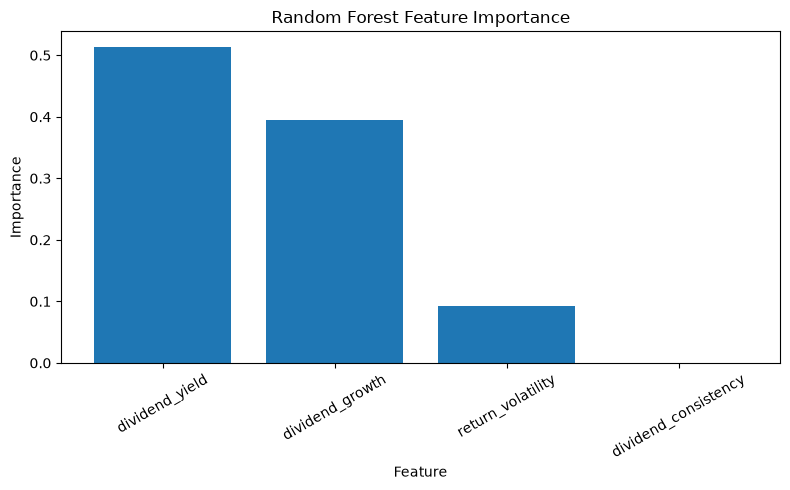

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [12]:
rf_comparison = pd.DataFrame({
    "Actual_Return": y_test.values,
    "Predicted_Return": rf_pred,
    "Residual": y_test.values - rf_pred
})

print(rf_comparison.head(10).to_string(index=False))

 Actual_Return  Predicted_Return  Residual
         29.36          13.55830  15.80170
         26.49          12.21010  14.27990
         19.75           4.17015  15.57985
         51.89          31.38625  20.50375
         41.98          28.37820  13.60180
          7.78          13.67605  -5.89605
          6.49           7.62130  -1.13130
         15.65          14.40100   1.24900
         14.89          11.72625   3.16375
         11.96          31.38630 -19.42630


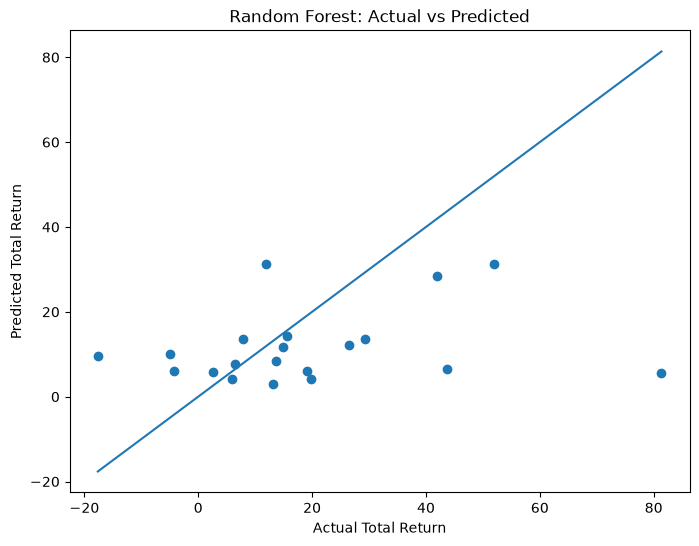

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_pred
)

min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.xlabel("Actual Total Return")
plt.ylabel("Predicted Total Return")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [14]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [rf_mae],
    "MSE": [rf_mse],
    "RMSE": [rf_rmse],
    "R2": [rf_r2]
})

rf_results.to_csv(
    "../datasets/processed/day19_random_forest_results.csv",
    index=False
)

print("Day 19 model results saved!")

Day 19 model results saved!


In [15]:
feature_importance.to_csv(
    "../datasets/processed/day19_random_forest_feature_importance.csv",
    index=False
)

print("Feature importance saved!")

Feature importance saved!


In [16]:
rf_comparison.to_csv(
    "../datasets/processed/day19_random_forest_predictions.csv",
    index=False
)

print("Random Forest predictions saved!")

Random Forest predictions saved!
